In [1]:
import pandas as pd

orders = pd.read_csv(r'C:\Users\pdeva\ecommerce\data\olist_orders_dataset.csv')
print(orders.shape)
print(orders.head())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

In [2]:
customers = pd.read_csv(r'C:\Users\pdeva\ecommerce\data\olist_customers_dataset.csv')
payments = pd.read_csv(r'C:\Users\pdeva\ecommerce\data\olist_order_payments_dataset.csv')
products = pd.read_csv(r'C:\Users\pdeva\ecommerce\data\olist_products_dataset.csv')
order_items = pd.read_csv(r'C:\Users\pdeva\ecommerce\data\olist_order_items_dataset.csv')

print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)

Customers: (99441, 5)
Payments: (103886, 5)
Products: (32951, 9)
Order Items: (112650, 7)


In [3]:
print("=== ORDERS ===")
print(orders.isnull().sum())

=== ORDERS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [4]:
# Keep only delivered orders
orders_clean = orders[orders['order_status'] == 'delivered']

# Drop rows with missing delivery dates
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

print("Orders before cleaning:", orders.shape[0])
print("Orders after cleaning:", orders_clean.shape[0])

Orders before cleaning: 99441
Orders after cleaning: 96470


In [5]:
# Merge orders with customers
df = orders_clean.merge(customers, on='customer_id')

# Merge with payments
df = df.merge(payments, on='order_id')

# Merge with order items
df = df.merge(order_items, on='order_id')

print("Final dataset shape:", df.shape)
print(df.head(2))

Final dataset shape: (115027, 22)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10-10 21:25:13   

  order_estimated_delivery_date                customer_unique_id  \
0           2017-10-18 00:00:00  7c396fd4830fd04220f754e42b4e5bff   
1           2017-10-18 00:00:00  7c396fd4830fd04220f754e42b4e5bff   

   customer_zip_code_prefix  ... payment_sequential payment_type  \
0                      3149  ...                  1  credit_card   
1               

In [6]:
# Convert date column to proper date format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Extract month and year
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

# Total revenue per month
monthly_revenue = df.groupby('month_year')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']

print(monthly_revenue)

      month     revenue
0   2016-10    61746.94
1   2016-12       19.62
2   2017-01   176491.49
3   2017-02   325782.66
4   2017-03   505735.83
5   2017-04   456108.32
6   2017-05   701119.60
7   2017-06   585400.98
8   2017-07   716069.98
9   2017-08   842689.94
10  2017-09   996279.59
11  2017-10   998609.62
12  2017-11  1548547.86
13  2017-12  1020067.26
14  2018-01  1374064.02
15  2018-02  1279970.45
16  2018-03  1435458.33
17  2018-04  1466607.15
18  2018-05  1480667.59
19  2018-06  1285396.78
20  2018-07  1306707.42
21  2018-08  1211240.09


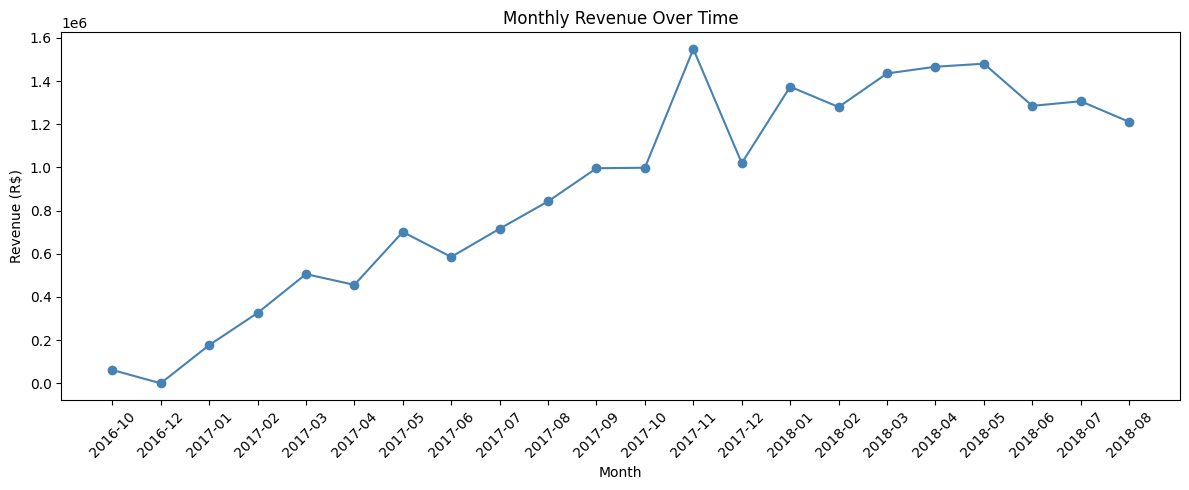

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['month'].astype(str), monthly_revenue['revenue'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.show()

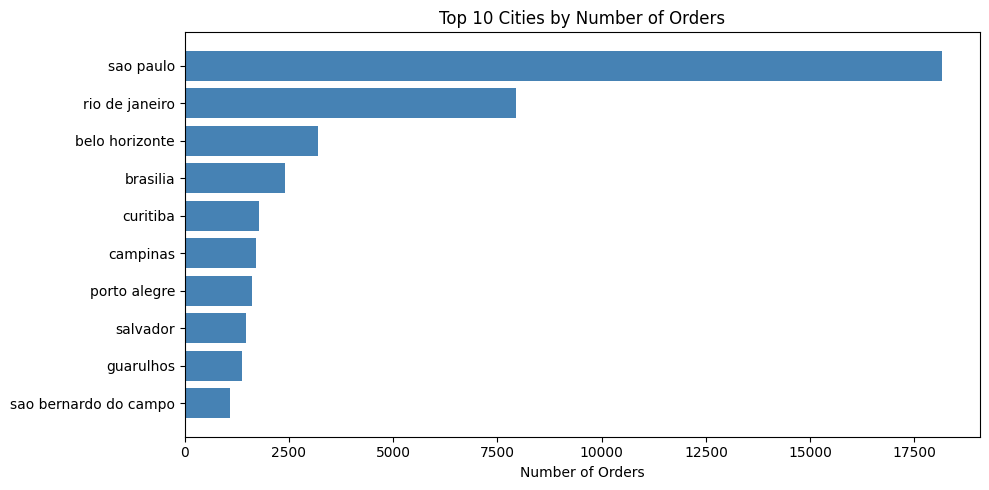

                       city  orders
3563              sao paulo   18163
3126         rio de janeiro    7950
449          belo horizonte    3188
553                brasilia    2405
1135               curitiba    1785
700                campinas    1707
2936           porto alegre    1614
3218               salvador    1473
1518              guarulhos    1363
3398  sao bernardo do campo    1093


In [8]:
top_cities = df.groupby('customer_city')['order_id'].count().reset_index()
top_cities.columns = ['city', 'orders']
top_cities = top_cities.sort_values('orders', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_cities['city'], top_cities['orders'], color='steelblue')
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_cities)

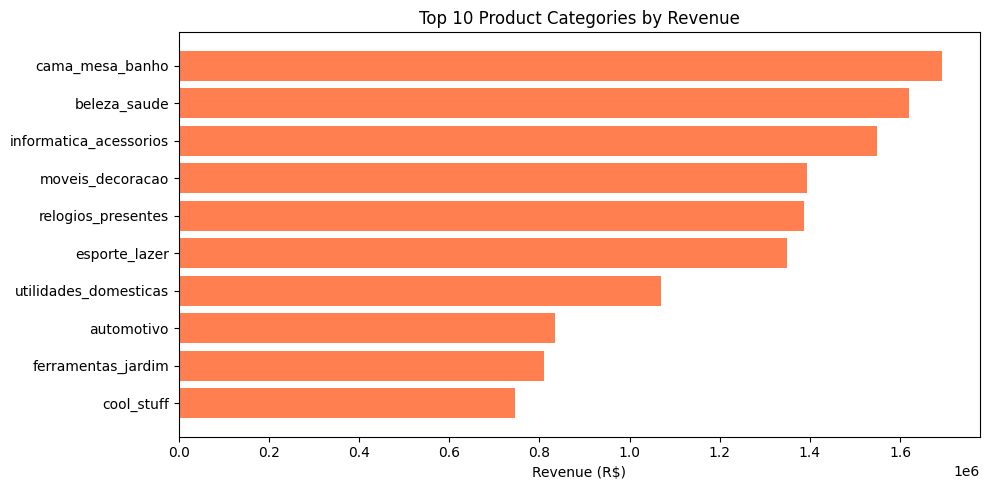

                  category     revenue
13         cama_mesa_banho  1692714.28
11            beleza_saude  1620684.04
44  informatica_acessorios  1549252.47
54        moveis_decoracao  1394466.93
66      relogios_presentes  1387046.31
32           esporte_lazer  1349252.93
72   utilidades_domesticas  1069787.97
8               automotivo   833610.84
40      ferramentas_jardim   810614.93
26              cool_stuff   744649.32


In [9]:
# Merge products to get category names
df2 = df.merge(products[['product_id', 'product_category_name']], on='product_id')

# Top 10 categories by revenue
top_categories = df2.groupby('product_category_name')['payment_value'].sum().reset_index()
top_categories.columns = ['category', 'revenue']
top_categories = top_categories.sort_values('revenue', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_categories['category'], top_categories['revenue'], color='coral')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_categories)

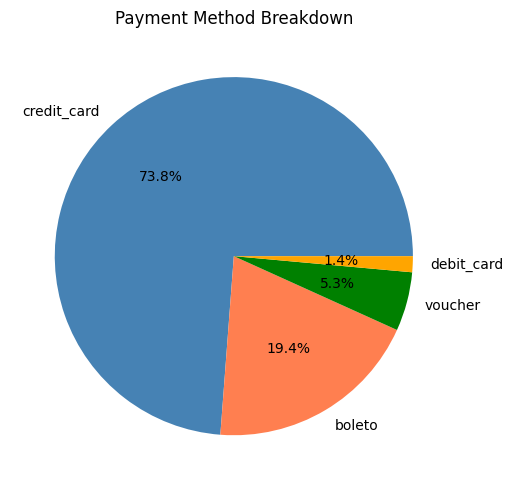

  payment_type  count
1  credit_card  84889
0       boleto  22362
3      voucher   6123
2   debit_card   1653


In [10]:
# Payment method breakdown
payment_types = df.groupby('payment_type')['order_id'].count().reset_index()
payment_types.columns = ['payment_type', 'count']
payment_types = payment_types.sort_values('count', ascending=False)

plt.figure(figsize=(8, 5))
plt.pie(payment_types['count'], labels=payment_types['payment_type'], 
        autopct='%1.1f%%', colors=['steelblue','coral','green','orange'])
plt.title('Payment Method Breakdown')
plt.tight_layout()
plt.show()

print(payment_types)

In [11]:
import datetime as dt

# Use max date as reference point
reference_date = df['order_purchase_timestamp'].max()

# Calculate RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(rfm.head(10))
print("\nRFM Summary:")
print(rfm.describe())

                        customer_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19
2  0000f46a3911fa3c0805444483337064      536          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      145          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      131          1     35.38
7  00053a61a98854899e70ed204dd4bafe      182          1    838.36
8  0005e1862207bf6ccc02e4228effd9a0      542          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      169          1    129.76

RFM Summary:
            recency     frequency       monetary
count  93349.000000  93349.000000   93349.000000
mean     236.944970      1.033423     211.837101
std      152.582794      0.209107     642.193495
min        0.000000      1.000000       9.590000
25%      113.00

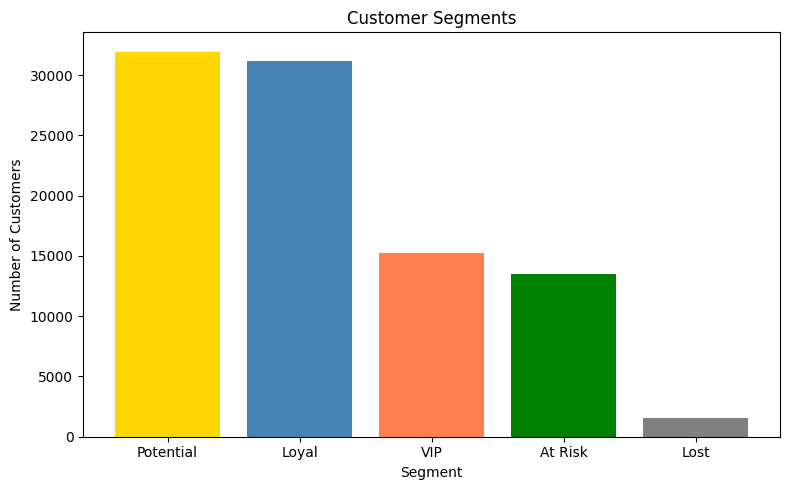

segment
Potential    31946
Loyal        31135
VIP          15229
At Risk      13519
Lost          1520
Name: count, dtype: int64


In [12]:
# Score each customer 1-4 on each RFM metric
rfm['r_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

# Combine scores
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Label segments
def segment_customer(row):
    score = int(row['r_score']) + int(row['f_score']) + int(row['m_score'])
    if score >= 10:
        return 'VIP'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Plot segments
segment_counts = rfm['segment'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(segment_counts.index, segment_counts.values, color=['gold','steelblue','coral','green','gray'])
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(segment_counts)

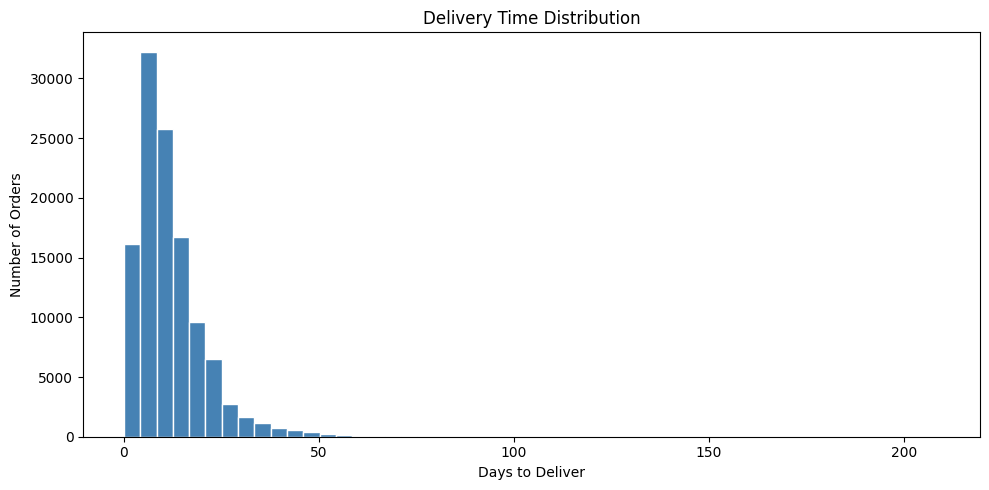

Average delivery time: 12.0 days
Fastest delivery: 0 days
Slowest delivery: 209 days
Orders delivered early: 105033
Orders delivered late: 8428


In [13]:
# Calculate delivery time in days
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_diff'] = df['estimated_days'] - df['delivery_days']

# Plot delivery time distribution
plt.figure(figsize=(10,5))
plt.hist(df['delivery_days'], bins=50, color='steelblue', edgecolor='white')
plt.title('Delivery Time Distribution')
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print("Average delivery time:", round(df['delivery_days'].mean(), 1), "days")
print("Fastest delivery:", df['delivery_days'].min(), "days")
print("Slowest delivery:", df['delivery_days'].max(), "days")
print("Orders delivered early:", (df['delivery_diff'] > 0).sum())
print("Orders delivered late:", (df['delivery_diff'] < 0).sum())